# VIETNAMESE TOXIC DETECT

In [1]:
!pip install -q underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.6/978.6 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 110.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.8.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.8.0 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
from underthesea import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay
from wordcloud import WordCloud

# Cấu hình hiển thị
pd.set_option('display.max_colwidth', 100)
sns.set(style="whitegrid")
%matplotlib inline

In [3]:
# --- 1. LOAD DATA ---
df_train = pd.read_csv('/kaggle/input/hate-speech-detection-vietnamese/train_df.csv')
df_val = pd.read_csv('/kaggle/input/hate-speech-detection-vietnamese/val_df.csv')
df_test = pd.read_csv('/kaggle/input/hate-speech-detection-vietnamese/test_df.csv')

# Gộp tất cả lại thành một tập lớn
df_full = pd.concat([df_train, df_val, df_test], ignore_index=True)

df_full.rename(columns={df_full.columns[0]: 'cmt_col', df_full.columns[1]: 'label'}, inplace=True)

In [4]:
# Xóa dữ liệu rỗng và trùng lặp
df_full.dropna(subset=['cmt_col', 'label'], inplace=True)
df_full.drop_duplicates(subset=['cmt_col'], inplace=True)

print(f"Tổng số dữ liệu sau khi gộp và lọc trùng: {len(df_full)} dòng")

Tổng số dữ liệu sau khi gộp và lọc trùng: 6753 dòng


In [5]:
vietnamese_stopwords = set([
    # stop word
    "thì", "là", "và", "của", "những", "các", "tại", "bị", "bởi", "với", "để", 
    "như", "này", "đó", "kia", "trong", "trên", "dưới", "cho", "về", "khi",
    "có", "không", "gì", "nào", "đâu", "rồi", "lại", "vẫn", "cũng", "đang",
    "đã", "sẽ", "phải", "nhưng", "tuy", "hoặc", "nếu", "vì", "mà", "ai", 
    "nó", "họ", "ta", "ông", "bà", "anh", "chị", "em", "mình", "cậu", "bạn",
    "người", "được", "ra", "vào", "lên", "xuống", "đi", "đến", "qua", "lắm",
    "rất", "quá", "ơi", "à", "ừ", "nhé", "nhỉ", "cả", "chi", "chứ", "kìa",

     # Đại từ nhân xưng mở rộng
    "tôi", "tao", "mày", "tụi", "chúng", "chúng tôi", "chúng ta",
    "hắn", "này", "kia", "đấy", "ấy",
    
    # Trợ từ, từ đệm, từ cảm thán
    "à", "á", "ạ", "ơ", "ờ", "ừ", "uh", "ồ", "ôi", "wow",
    "ha", "hả", "hử", "ơ", "ok", "okay",

    # Từ chỉ thời gian chung chung
    "hôm", "nay", "qua", "mai", "nữa", "luôn", "liền",

    # Từ chỉ địa điểm chung chung
    "đây", "đấy", "kia", "đó",

    # Từ nối mở rộng
    "song", "như thể", "giống như", "tuy nhiên", "bởi vì",
    "ngoài ra", "thậm chí",

    # Từ phủ định
    "chẳng", "chả", "không hề", "chưa", "chẳng hề",

    # Từ chỉ mức độ/nhấn mạnh
    "siêu", "quá trời", "cực", "vô cùng", "hết sức", "kinh",
    "khá", "hơi", "đậm", "nhẹ", "toàn", "toàn là",

    # Từ chỉ số lượng chung chung
    "một ít", "một chút", "ít", "nhiều", "mọi", "tất cả", "mỗi",

    # Từ hội thoại phổ biến
    "vậy", "thế", "thôi", "nhé", "nhỉ", "chứ gì", "mà nhỉ",
    "haizz", "haha", "hihi", "kkk",

    # Biến thể không dấu (hỗ trợ text thiếu dấu)
    "thi", "la", "va", "cua", "nhung", "cac", "tai", "bi",
    "boi", "voi", "de", "nhu", "nay", "do", "kia", "trong",
    "tren", "duoi", "cho", "ve", "khi", "co", "khong", "gi",
    "n nao", "dau", "roi", "lai", "van", "cung", "dang",
    "da", "se", "phai", "nhung", "tuy", "hoac", "neu",
    "vi", "ma", "ai", "no", "ho", "ta", "ong", "ba", "anh",
    "chi", "em", "minh", "cau", "ban", "nguoi", "duoc",
    "ra", "vao", "len", "xuong", "di", "den", "qua",
    "lam", "rat", "qua", "oi", "a", "u", "nhe", "nhi",
    "ca", "chi", "chu", "kia"
])
def clean_text(text):
    text = str(text).lower() 
    # Xóa URL
    text = re.sub(r'http\S+', '', text)
    # Xóa ký tự đặc biệt
    text = re.sub(r'[^\w\s]', ' ', text)
    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    # --- LOẠI BỎ STOPWORDS ---
    words = text.split()
    words = [w for w in words if w not in vietnamese_stopwords]
    return " ".join(words)

def vietnamese_tokenizer(text):
    if not text: return ""
    return word_tokenize(text, format="text")

print("Đang tiến hành làm sạch và tách từ (Vui lòng đợi)...")

# Áp dụng làm sạch sơ bộ
df_full['text_clean'] = df_full['cmt_col'].apply(clean_text)

# Áp dụng tách từ (Underthesea)
df_full['text_tokenized'] = df_full['text_clean'].apply(vietnamese_tokenizer)


print("Mẫu dữ liệu sau xử lý:")
display(df_full[['cmt_col', 'label', 'text_tokenized']].head(10))

Đang tiến hành làm sạch và tách từ (Vui lòng đợi)...
Mẫu dữ liệu sau xử lý:


,cmt_col,label,text_tokenized
0,cặc,1.0,cặc
1,đr hết thời cày rank bk còn ngợp,0.0,đr hết thời cày rank bk còn ngợp
2,Diễn viên hô ni hút mà ngại gì mấy khác kk,0.0,diễn_viên hô ni hút_ngại mấy khác kk
3,Toàn bọn vô công rồi nghề ngồi sủa ăn lương tháng chứ vinh quang gì? Bản thân hiểu rõ hơn ai hết...,2.0,bọn vô_công nghề ngồi sủa ăn lương tháng vinh_quang bản_thân hiểu rõ hơn hết đồng_tiền bát gạo n...
4,lên kim cương bố ỉa vào mồm mày với cái lối lên đồ 10 game như 1 này :)))) bao giờ live rank kc ...,1.0,kim_cương bố ỉa mồm cái lối đồ 10 game 1 bao_giờ live rank kc tag bố m
5,"Con bà chúng nó làm lòng vòng để tìm cách tham ô tham nhũng, chứ xử lý nguồn gốc gây ô nhiễm chu...",1.0,con làm lòng_vòng tìm cách tham_ô tham_nhũng xử_lý nguồn_gốc gây ô_nhiễm chuyển xử_lý dòng_chảy ...
6,why cái lồn,1.0,why cái lồn
7,Su Quỳnh chéo avt hộ vs ạ,0.0,su quỳnh_chéo avt hô vs
8,Phàm :)) vlon thanh niên,1.0,phàm vlon thanh_niên
9,Bắt được mấy thằng trộm xe. Nên chặt tay nó,1.0,bă t đươ c mâ y_thă ng trô m xe nên chă t tay


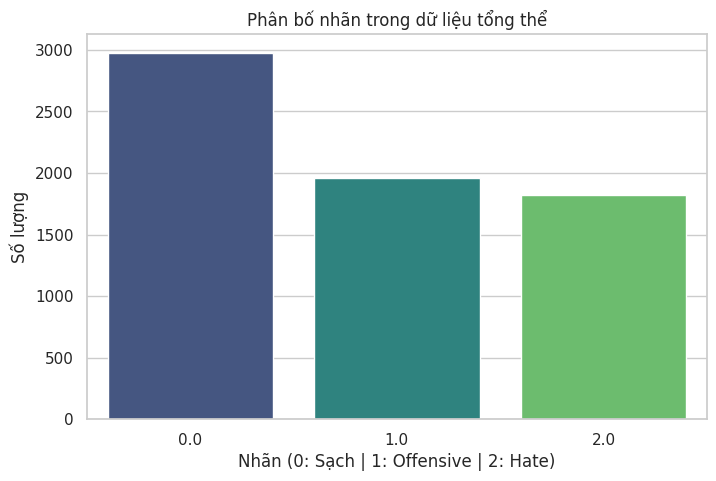

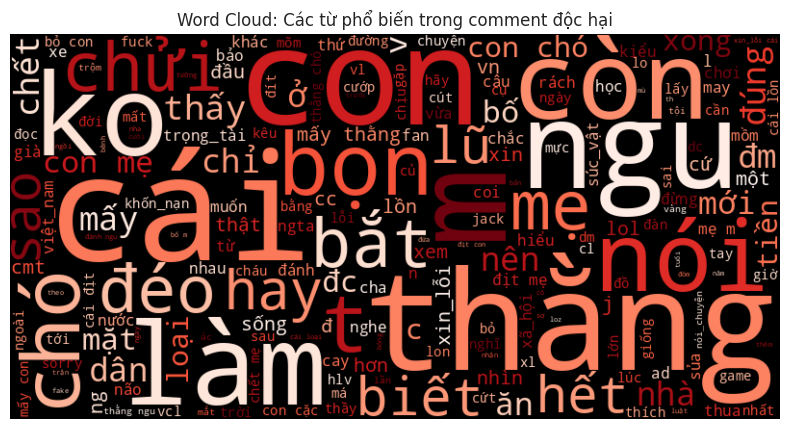

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

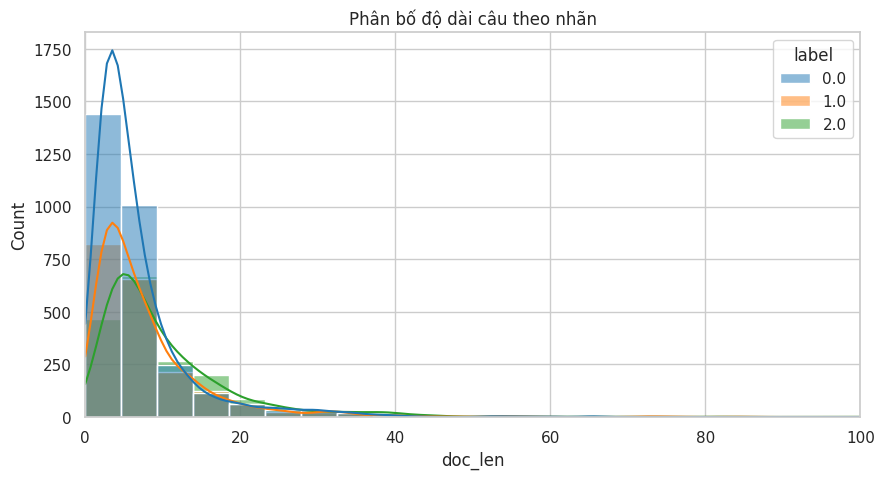

In [6]:
# 1. Phân bố nhãn (Label Distribution)
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df_full, palette='viridis')
plt.title('Phân bố nhãn trong dữ liệu tổng thể')
plt.xlabel('Nhãn (0: Sạch | 1: Offensive | 2: Hate)')
plt.ylabel('Số lượng')
plt.show()

# 2. WordCloud - Từ ngữ xuất hiện nhiều nhất ở các comment độc hại (Label > 0)
toxic_text = " ".join(df_full[df_full['label'] > 0]['text_tokenized'])
if len(toxic_text) > 0:
    wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(toxic_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud: Các từ phổ biến trong comment độc hại')
    plt.show()

# 3. Phân bố độ dài comment
df_full['doc_len'] = df_full['text_tokenized'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.histplot(data=df_full, x='doc_len', hue='label', bins=30, kde=True, palette='tab10')
plt.title('Phân bố độ dài câu theo nhãn')
plt.xlim(0, 100) # Giới hạn hiển thị câu dưới 100 từ cho dễ nhìn
plt.show()

In [7]:
# Tách X và y
X = df_full['text_tokenized']
y = df_full['label']

# Chia train/test (85% - 15%)
# stratify=y giúp đảm bảo tỉ lệ nhãn toxic/non-toxic ở tập test giống tập train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

print(f"Kích thước Train: {len(X_train)} | Kích thước Test: {len(X_test)}")

# --- HUẤN LUYỆN MODEL ---
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), min_df=2, max_df=0.9)),
    # LinearSVR cho bài toán hồi quy
    ('regressor', LinearSVR(epsilon=0.1, C=1.0, random_state=42, max_iter=5000)) 
])

print("Đang huấn luyện mô hình...")
pipeline.fit(X_train, y_train)
print("Huấn luyện xong!")

Kích thước Train: 5740 | Kích thước Test: 1013
Đang huấn luyện mô hình...
Huấn luyện xong!


Sai số toàn phương trung bình (MSE): 0.2943

--- BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ---
                 precision    recall  f1-score   support

    Sạch (Safe)       0.69      0.94      0.79       447
Độc hại (Toxic)       0.94      0.66      0.77       566

       accuracy                           0.78      1013
      macro avg       0.81      0.80      0.78      1013
   weighted avg       0.83      0.78      0.78      1013



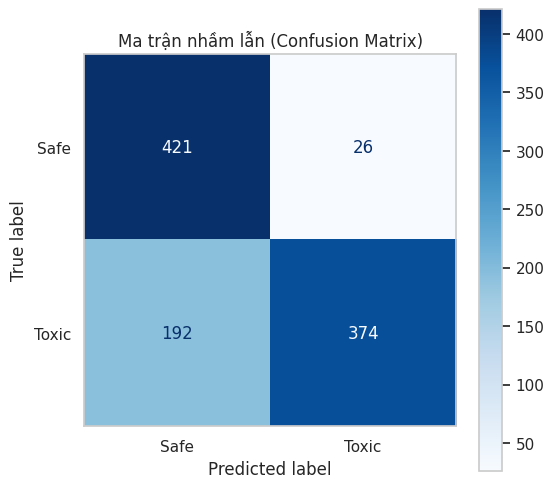

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


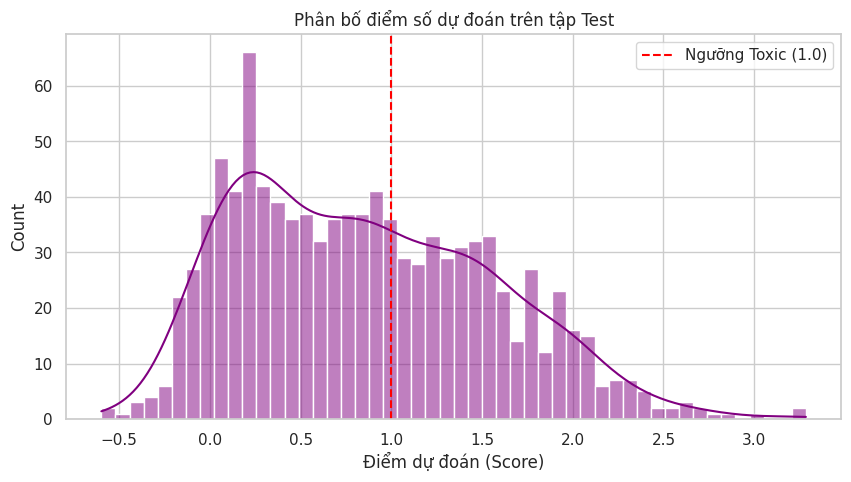

In [8]:
# Dự đoán trên tập Test vói ngưỡng 1
y_pred_score = pipeline.predict(X_test)

# --- 1. Đánh giá Hồi quy ---
mse = mean_squared_error(y_test, y_pred_score)
print(f"Sai số toàn phương trung bình (MSE): {mse:.4f}")

# --- 2. Chuyển đổi sang bài toán Phân loại để đánh giá ---
# Quy ước ngưỡng: < 1.0 là Sạch (0), >= 1.0 là Toxic (1)
threshold = 1.0

y_pred_binary = [1 if score >= threshold else 0 for score in y_pred_score]
y_true_binary = [1 if label >= threshold else 0 for label in y_test]

print("\n--- BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ---")
print(classification_report(y_true_binary, y_pred_binary, target_names=['Sạch (Safe)', 'Độc hại (Toxic)']))

# --- 3. Trực quan hóa Confusion Matrix ---
cm = confusion_matrix(y_true_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Toxic'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.grid(False)
plt.show()

# --- 4. Biểu đồ phân bố điểm dự đoán ---
plt.figure(figsize=(10, 5))
sns.histplot(y_pred_score, bins=50, kde=True, color='purple')
plt.axvline(x=1.0, color='red', linestyle='--', label='Ngưỡng Toxic (1.0)')
plt.title('Phân bố điểm số dự đoán trên tập Test')
plt.xlabel('Điểm dự đoán (Score)')
plt.legend()
plt.show()


>> Đã tìm thấy ngưỡng tối ưu: 0.6272
>> F1-Score cao nhất đạt được: 0.8641

--- BÁO CÁO PHÂN LOẠI (Với ngưỡng 0.6272) ---
                 precision    recall  f1-score   support

    Sạch (Safe)       0.84      0.81      0.82       447
Độc hại (Toxic)       0.85      0.88      0.86       566

       accuracy                           0.85      1013
      macro avg       0.84      0.84      0.84      1013
   weighted avg       0.85      0.85      0.85      1013



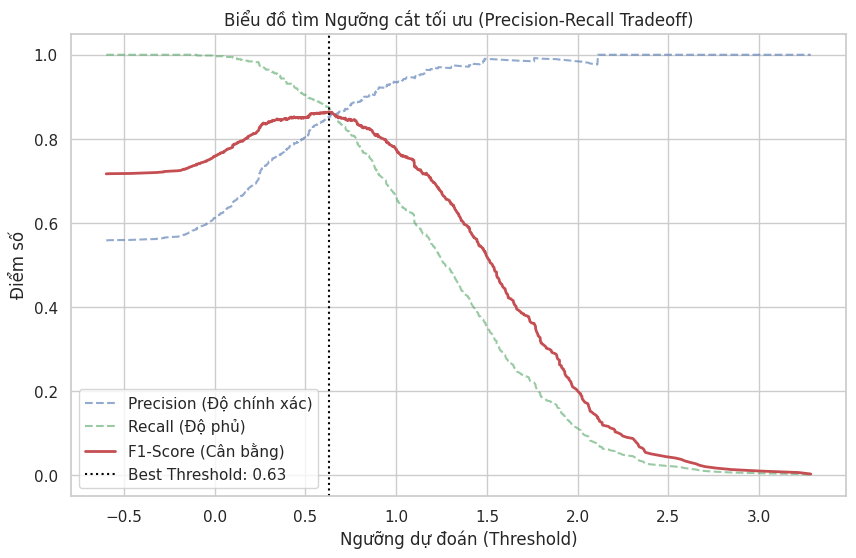

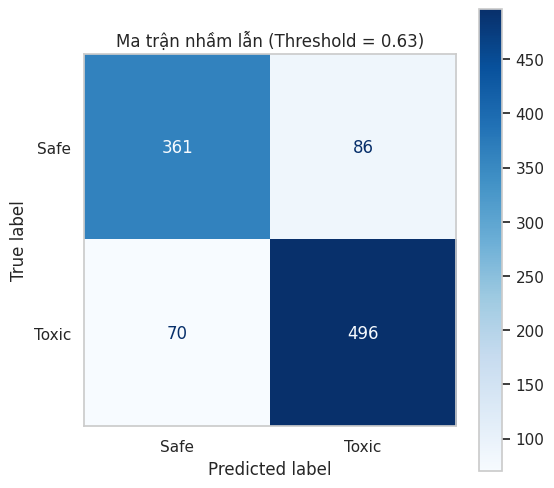

In [9]:
from sklearn.metrics import precision_recall_curve, f1_score

# TỰ ĐỘNG TÌM NGƯỠNG TỐI ƯU

# 1: Xác định nhãn thật 
#  Dữ liệu gốc nhãn >= 1 là Toxic, < 1 là Sạch
y_true_binary = [1 if label >= 1.0 else 0 for label in y_test]

# Bước 2: Tính toán Precision, Recall cho TẤT CẢ các ngưỡng có thể
precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_pred_score)

# Bước 3: Tính F1-Score cho từng ngưỡng
# Công thức F1 = 2 * (P * R) / (P + R)
# Thêm eps để tránh chia cho 0
numerator = 2 * precisions * recalls
denominator = precisions + recalls
f1_scores = np.divide(numerator, denominator, out=np.zeros_like(denominator), where=denominator!=0)

# Bước 4: Tìm vị trí có F1 cao nhất
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\n>> Đã tìm thấy ngưỡng tối ưu: {best_threshold:.4f}")
print(f">> F1-Score cao nhất đạt được: {best_f1:.4f}")

# --- 3. ÁP DỤNG NGƯỠNG TỐI ƯU ĐỂ ĐÁNH GIÁ ---
print(f"\n--- BÁO CÁO PHÂN LOẠI (Với ngưỡng {best_threshold:.4f}) ---")

# Tạo nhãn dự đoán dựa trên ngưỡng vừa tìm được
y_pred_optimal = [1 if score >= best_threshold else 0 for score in y_pred_score]

print(classification_report(y_true_binary, y_pred_optimal, target_names=['Sạch (Safe)', 'Độc hại (Toxic)']))

# --- 4. TRỰC QUAN HÓA: BIỂU ĐỒ TÌM NGƯỠNG ---
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision (Độ chính xác)", alpha=0.6)
plt.plot(thresholds, recalls[:-1], "g--", label="Recall (Độ phủ)", alpha=0.6)
plt.plot(thresholds, f1_scores[:-1], "r-", label="F1-Score (Cân bằng)", linewidth=2)

plt.axvline(x=best_threshold, color='black', linestyle=':', label=f'Best Threshold: {best_threshold:.2f}')
plt.title('Biểu đồ tìm Ngưỡng cắt tối ưu (Precision-Recall Tradeoff)')
plt.xlabel('Ngưỡng dự đoán (Threshold)')
plt.ylabel('Điểm số')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# --- 5. CONFUSION MATRIX VỚI NGƯỠNG MỚI ---
cm = confusion_matrix(y_true_binary, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Toxic'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title(f'Ma trận nhầm lẫn (Threshold = {best_threshold:.2f})')
plt.grid(False)
plt.show()

In [10]:
model_filename = 'toxic_detect_model_v2.pkl'
joblib.dump(pipeline, model_filename)
print(f"Mô hình đã được lưu thành công tại: {model_filename}")

Mô hình đã được lưu thành công tại: toxic_detect_model_v2.pkl


In [11]:
import joblib
from underthesea import word_tokenize


THRESHOLD = 0.6272


class ToxicFilterSystem:
    def __init__(self, model_path):
        self.model = joblib.load(model_path)
        print("System loaded successfully.")
    
    def _preprocess(self, text):
        # Đảm bảo logic tiền xử lý giống hệt lúc train
        if not text: return ""
        text = str(text).lower()
        return word_tokenize(text, format="text")

    def analyze(self, text):
        tokenized_text = self._preprocess(text)
        score = self.model.predict([tokenized_text])[0]
        score = round(score, 3)
        
        # Logic nghiệp vụ
        if score <= threshold:
            label = "safe"
            message = "✅ Nội dung hợp lệ"
       
        else:
            label = "block"
            message = "❌ Vi phạm tiêu chuẩn cộng đồng"
            
        return {
            "original_text": text,
            "toxicity_score": score,
            "label": label,
            "message": message
        }

# --- DEMO SỬ DỤNG ---
filter_sys = ToxicFilterSystem('toxic_detect_model_v2.pkl')

test_comments = [
    "Shop giao hàng nhanh quá, cảm ơn nhé",
    "Sản phẩm như cái quần què, phí tiền",
    "Hàng giao hơi chậm xíu nhưng chất lượng ổn",
    "mày lừa đảo à",
    "đm lừa đảo à",
    "thằng bắc kỳ"
]

for cmt in test_comments:
    result = filter_sys.analyze(cmt)
    print(f"[{result['label'].upper()}] Score: {result['toxicity_score']} | {result['original_text']} |  {result['message']}")

System loaded successfully.
[SAFE] Score: 0.076 | Shop giao hàng nhanh quá, cảm ơn nhé |  ✅ Nội dung hợp lệ
[SAFE] Score: 0.511 | Sản phẩm như cái quần què, phí tiền |  ✅ Nội dung hợp lệ
[SAFE] Score: 0.248 | Hàng giao hơi chậm xíu nhưng chất lượng ổn |  ✅ Nội dung hợp lệ
[SAFE] Score: 0.349 | mày lừa đảo à |  ✅ Nội dung hợp lệ
[BLOCK] Score: 1.092 | đm lừa đảo à |  ❌ Vi phạm tiêu chuẩn cộng đồng
[BLOCK] Score: 1.61 | thằng bắc kỳ |  ❌ Vi phạm tiêu chuẩn cộng đồng
